Cтруктура данных

<img src="https://imgur.com/HRhd2Y0.png" width="600" alt="Описание">

Компания запустила A/B-тест: части пользователей (тестовая группа) показывали обещание "Гарантированная доставка за 3 дня", а контрольной группе — стандартные условия. Нам нужно оценить, повлияла ли эта функция на средний чек и возвращаемость пользователей.

In [252]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [253]:
orders_items = pd.DataFrame(pd.read_csv('../data/olist_order_items_dataset.csv'))
orders_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [254]:
orders = pd.DataFrame(pd.read_csv('../data/olist_orders_dataset.csv'))
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [255]:
customers = pd.DataFrame(pd.read_csv('../data/olist_customers_dataset.csv'))
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [256]:
print(orders.shape)
print(orders_items.shape)
print(customers.shape)

(99441, 8)
(112650, 7)
(99441, 5)


In [257]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [258]:
orders_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [259]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [260]:
customers_orders = pd.merge(customers, orders, on='customer_id')
customers_orders.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13 00:00:00
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10 00:00:00
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15 00:00:00


In [261]:
orders_price = pd.DataFrame(orders_items.groupby('order_id', as_index=False)[['price', 'freight_value']].sum())
orders_price['total_price'] = orders_price['price'] + orders_price['freight_value']
orders_price.head()

,order_id,price,freight_value,total_price
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,218.04


In [262]:
customers_orders_with_prices = pd.merge(customers_orders, orders_price, on='order_id', how='inner')
customers_orders_with_prices.head(2)
# customers_orders_with_prices.shape

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,total_price
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00,124.99,21.88,146.87
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00,289.00,46.48,335.48


In [263]:
customers_orders_with_prices['purchase_year'] = pd.to_datetime(customers_orders_with_prices['order_purchase_timestamp']).dt.year
customers_orders_with_prices['purchase_month'] = pd.to_datetime(customers_orders_with_prices['order_purchase_timestamp']).dt.month
customers_orders_with_prices['purchase_day'] = pd.to_datetime(customers_orders_with_prices['order_purchase_timestamp']).dt.day
customers_orders_with_prices.head(1)
# customers_orders_with_prices.shape

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,total_price,purchase_year,purchase_month,purchase_day
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00,124.99,21.88,146.87,2017,5,16


In [264]:
customers_orders_with_prices.isnull().sum()

customer_id                         0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_id                            0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  14
order_delivered_carrier_date     1009
order_delivered_customer_date    2190
order_estimated_delivery_date       0
price                               0
freight_value                       0
total_price                         0
purchase_year                       0
purchase_month                      0
purchase_day                        0
dtype: int64

In [265]:
(customers_orders_with_prices['order_status']).unique()

array(['delivered', 'invoiced', 'shipped', 'processing', 'canceled',
       'unavailable', 'approved'], dtype=object)

In [266]:
customers_orders_with_prices['order_status'].value_counts()

order_status
delivered      96478
shipped         1106
canceled         461
invoiced         312
processing       301
unavailable        6
approved           2
Name: count, dtype: int64

удалим все заказы, кроме отправленных и доставленных

In [267]:
customers_orders_with_prices = customers_orders_with_prices[customers_orders_with_prices['order_status'].isin(['delivered', 'shipped'])]
customers_orders_with_prices.shape

(97584, 18)

In [268]:
(customers_orders_with_prices['order_status']).unique()

array(['delivered', 'shipped'], dtype=object)

In [269]:
customers_orders_with_prices.head(1)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,total_price,purchase_year,purchase_month,purchase_day
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00,124.99,21.88,146.87,2017,5,16


In [270]:
orders_in_august_2017 = customers_orders_with_prices[(customers_orders_with_prices['purchase_year'] == 2017) & (customers_orders_with_prices['purchase_month'] == 8)].copy()
orders_in_august_2017.head(3)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,total_price,purchase_year,purchase_month,purchase_day
20,154c4ded6991bdfa3cd249d11abf4130,e607ede0e63436308660236f5a52da5e,88034,florianopolis,SC,830d8b3e6875ef6165ffc33219ab4fea,delivered,2017-08-13 10:03:36,2017-08-13 10:24:04,2017-08-14 18:43:45,2017-08-19 12:37:49,2017-09-20 00:00:00,105.00,18.00,123.00,2017,8,13
37,54f755c3fd2709231f9964a1430c5218,40febde16f4718a5def537786473b0be,93415,novo hamburgo,RS,d4668cd8ef48b78df597195703c95da2,delivered,2017-08-10 13:01:54,2017-08-10 13:23:32,2017-08-14 19:44:58,2017-08-21 13:42:55,2017-09-01 00:00:00,44.90,15.10,60.00,2017,8,10
96,369708cabd9831ea6fde670a3b602a92,94b731a41867b47c3856e324840c4c99,3636,sao paulo,SP,cf50fec98e2167d836c09c0ed57ba841,delivered,2017-08-27 15:05:33,2017-08-27 15:24:23,2017-08-28 20:22:13,2017-08-29 15:56:57,2017-09-08 00:00:00,12.99,9.34,22.33,2017,8,27


In [271]:
print(len(orders_in_august_2017['customer_unique_id'].unique()))

4155


In [272]:
np.random.seed(11)

In [273]:
customers_unique = orders_in_august_2017['customer_unique_id'].unique()
customers_unique

array(['e607ede0e63436308660236f5a52da5e',
       '40febde16f4718a5def537786473b0be',
       '94b731a41867b47c3856e324840c4c99', ...,
       '9b03f2721fb73962781bae9322b0c071',
       '8c8173e547e020f411aa55b2fceed861',
       '81720bfb69887fe95390723af9748e9f'], dtype=object)

In [274]:
np.random.shuffle(customers_unique)

In [275]:
split_point = len(customers_unique) // 2
group_a = customers_unique[:split_point]
group_b = customers_unique[split_point:]

In [276]:
orders_in_august_2017['ab_group'] = orders_in_august_2017['customer_unique_id'].apply(
    lambda x: 'A' if x in group_a else 'B')
orders_in_august_2017.head(3)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,total_price,purchase_year,purchase_month,purchase_day,ab_group
20,154c4ded6991bdfa3cd249d11abf4130,e607ede0e63436308660236f5a52da5e,88034,florianopolis,SC,830d8b3e6875ef6165ffc33219ab4fea,delivered,2017-08-13 10:03:36,2017-08-13 10:24:04,2017-08-14 18:43:45,2017-08-19 12:37:49,2017-09-20 00:00:00,105.00,18.00,123.00,2017,8,13,B
37,54f755c3fd2709231f9964a1430c5218,40febde16f4718a5def537786473b0be,93415,novo hamburgo,RS,d4668cd8ef48b78df597195703c95da2,delivered,2017-08-10 13:01:54,2017-08-10 13:23:32,2017-08-14 19:44:58,2017-08-21 13:42:55,2017-09-01 00:00:00,44.90,15.10,60.00,2017,8,10,A
96,369708cabd9831ea6fde670a3b602a92,94b731a41867b47c3856e324840c4c99,3636,sao paulo,SP,cf50fec98e2167d836c09c0ed57ba841,delivered,2017-08-27 15:05:33,2017-08-27 15:24:23,2017-08-28 20:22:13,2017-08-29 15:56:57,2017-09-08 00:00:00,12.99,9.34,22.33,2017,8,27,A


In [277]:
orders_in_august_2017['ab_group'].value_counts()

ab_group
B    2118
A    2116
Name: count, dtype: int64

<Axes: xlabel='total_price', ylabel='Count'>

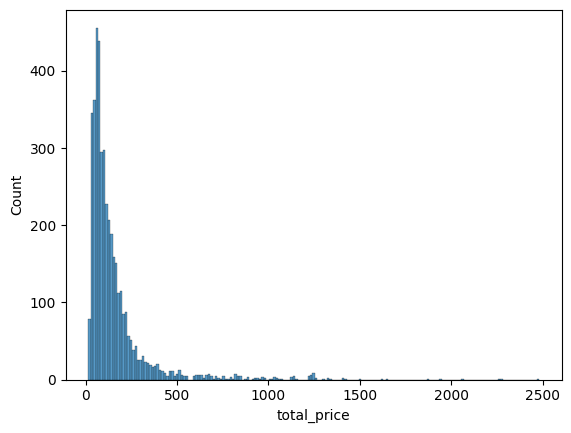

In [278]:
sns.histplot(orders_in_august_2017['total_price'])

<Axes: xlabel='ab_group', ylabel='total_price'>

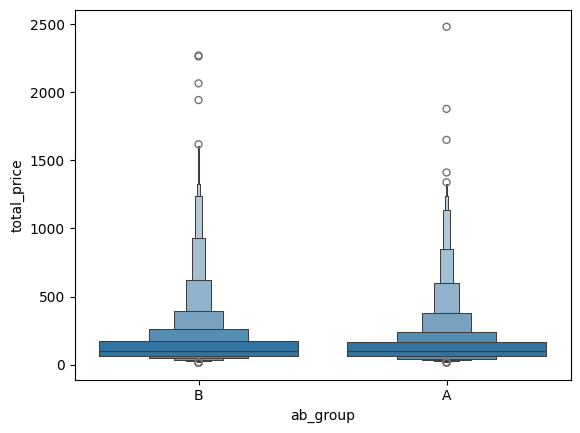

In [279]:
sns.boxenplot(x='ab_group', y='total_price', data=orders_in_august_2017)

H0: средний чек в тесте = среднему чеку в контроле

H1: средний чек в тесте ≠ среднему чеку в контроле

In [280]:
total_price_a = orders_in_august_2017[orders_in_august_2017['ab_group'] == 'A']['total_price'].values
total_price_a

array([ 60.  ,  22.33, 164.26, ...,  63.1 , 103.55,  32.91])

In [281]:
total_price_b = orders_in_august_2017[orders_in_august_2017['ab_group'] == 'B']['total_price'].values
total_price_b

array([123.  ,  58.59, 109.29, ..., 226.24,  77.57,  64.  ])

Text(0.5, 1.0, 'Группа B')

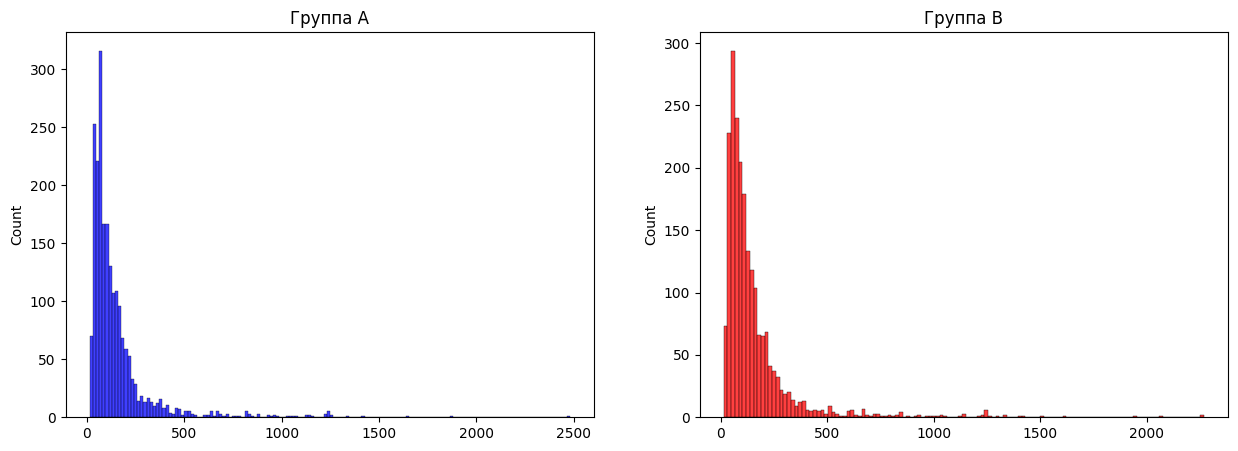

In [282]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(total_price_a, ax=axes[0], color='blue')
axes[0].set_title('Группа A')
sns.histplot(total_price_b, ax=axes[1], color='red')
axes[1].set_title('Группа B')

Основные метрики
AOV (средний чек)
retention (доля вернувшихся)


In [283]:
aov_total_price_a = total_price_a.sum() / len(total_price_a)
aov_total_price_a

149.61477315689982

In [284]:
aov_total_price_b = total_price_b.sum() / len(total_price_b)
aov_total_price_b

158.48262511803588

In [285]:
stats.mannwhitneyu(total_price_a, total_price_b)

MannwhitneyuResult(statistic=2159295.0, pvalue=0.040315610827671225)

In [286]:
ci_a = stats.bootstrap(
    (total_price_a,), 
    statistic=np.mean, 
    confidence_level=0.95,
    n_resamples=10000,
    method='BCa' 
)
print(f"95% CI для группы A: [{ci_a.confidence_interval.low:.2f}, {ci_a.confidence_interval.high:.2f}]")

95% CI для группы A: [142.59, 157.84]


In [287]:
ci_b = stats.bootstrap(
    (total_price_b,), 
    statistic=np.mean, 
    confidence_level=0.95,
    n_resamples=10000,
    method='BCa' 
)
print(f"95% CI для группы B: [{ci_b.confidence_interval.low:.2f}, {ci_b.confidence_interval.high:.2f}]")

95% CI для группы B: [150.87, 167.39]


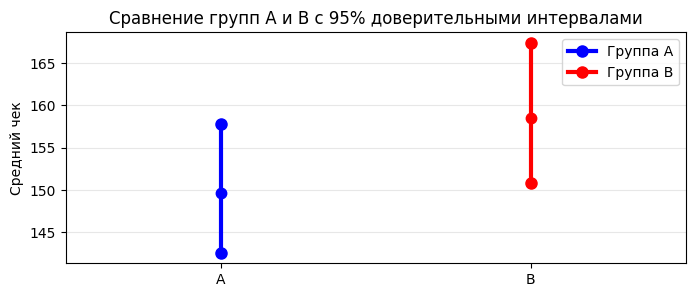

In [288]:
mean_a = np.mean(total_price_a) 
mean_b = np.mean(total_price_b)

ci_a_bounds = [ci_a.confidence_interval.low, ci_a.confidence_interval.high]
ci_b_bounds = [ci_b.confidence_interval.low, ci_b.confidence_interval.high]

plt.figure(figsize=(8, 3))

plt.plot([1, 1], ci_a_bounds, 'bo-', linewidth=3, markersize=8, label='Группа A')
plt.plot([2, 2], ci_b_bounds, 'ro-', linewidth=3, markersize=8, label='Группа B')
plt.plot(1, mean_a, 'b.', markersize=15)
plt.plot(2, mean_b, 'r.', markersize=15)

plt.xlim(0.5, 2.5)
plt.xticks([1, 2], ['A', 'B'])
plt.ylabel('Средний чек')
plt.title('Сравнение групп A и B с 95% доверительными интервалами')
plt.grid(True, alpha=0.3, axis='y')
plt.legend()
plt.show()

In [289]:
stats.mannwhitneyu(total_price_a, total_price_b)
p_value = stats.mannwhitneyu(total_price_a, total_price_b)[1]
p_value

0.040315610827671225

In [290]:
def business_conclusion(p_value, mean_a, mean_b):
    print("ВЫВОДЫ")    
    if p_value < 0.05:
        print("СТАТИСТИЧЕСКИ ЗНАЧИМЫЙ РЕЗУЛЬТАТ")
        
        if mean_b > mean_a:
            print("Группа B показала лучше результат:")
            print(f"Средний чек выше на {mean_b - mean_a:.2f} ({((mean_b - mean_a)/mean_a*100):.1f}%)")
            
        else:
            print("Группа A показала лучше результат")
            print(f"Средний чек выше на {mean_a - mean_b:.2f}")
    else:
        print("СТАТИСТИЧЕСКИ НЕЗНАЧИМЫЙ РЕЗУЛЬТАТ")
        print("Разница может быть случайной")

business_conclusion(p_value, mean_a, mean_b)

ВЫВОДЫ
СТАТИСТИЧЕСКИ ЗНАЧИМЫЙ РЕЗУЛЬТАТ
Группа B показала лучше результат:
Средний чек выше на 8.87 (5.9%)
